# DecodeLabs Internship - Project 4

## Image Text Recognition using OCR

This notebook explains the full implementation of a basic OCR project. The goal is to read text from an image using Python libraries.

## Project Objective

The objective of this project is to implement a basic image/text recognition task using available libraries. The system loads an image, preprocesses it, extracts text using OCR, and saves the result.

## Libraries Used

- OpenCV: for image processing
- pytesseract: for OCR text extraction
- Matplotlib: for displaying images
- os: for working with file paths

In [19]:
import os
import cv2
import pytesseract
import matplotlib.pyplot as plt

# If Tesseract is not added to PATH on Windows, uncomment and edit this line:
pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"

## Step 1: Load the Image

The input image is loaded from the `sample_images` folder.

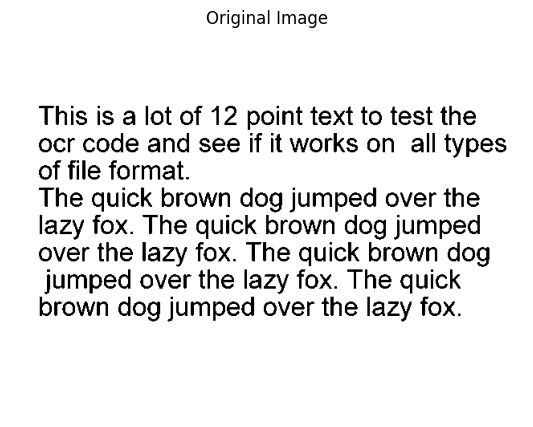

In [20]:
image_path = os.path.join('sample_images', 'sample_text.png')
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError('Image not found. Please check the image path.')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Original Image')
plt.show()

## Step 2: Convert to Grayscale

The image is converted to grayscale to reduce complexity and focus on intensity values instead of color channels.

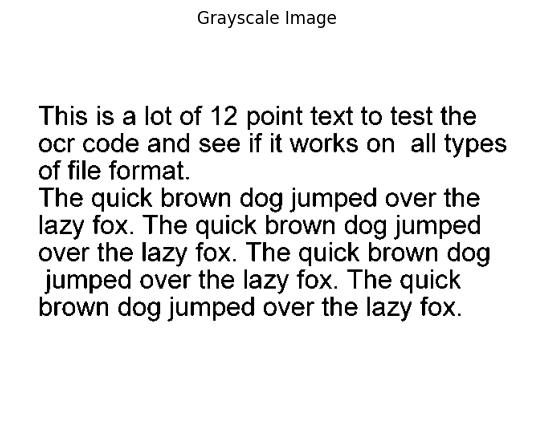

In [21]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Grayscale Image')
plt.show()

## Step 3: Apply Gaussian Blur

Gaussian blur helps reduce noise and makes the OCR process more stable.

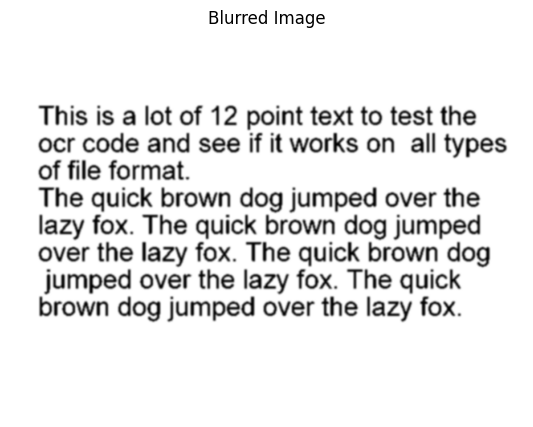

In [22]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(10, 5))
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.title('Blurred Image')
plt.show()

## Step 4: Apply Adaptive Thresholding

Adaptive thresholding converts the image into black and white. This makes the text more visible and easier for OCR to detect.

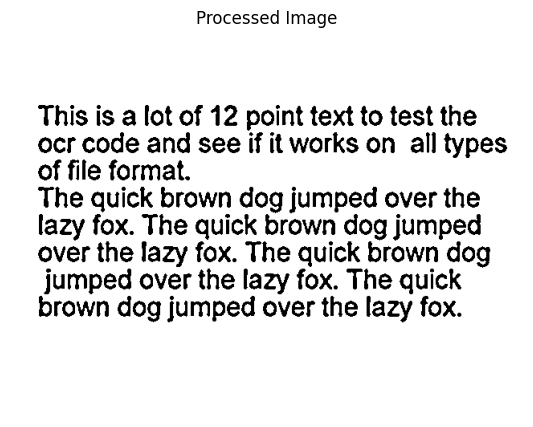

In [23]:
processed = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31,
    11
)

plt.figure(figsize=(10, 5))
plt.imshow(processed, cmap='gray')
plt.axis('off')
plt.title('Processed Image')
plt.show()

## Step 5: Extract Text using OCR

The processed image is passed to pytesseract to extract readable text.

In [24]:
extracted_text = pytesseract.image_to_string(processed)
print('Extracted Text:')
print('-' * 60)
print(extracted_text)

Extracted Text:
------------------------------------------------------------
This is a lot of 12 point text to test the
ocr code and see if it works on all types
of file format.

The quick brown dog jumped over the
lazy fox. The quick brown dog jumped
over the lazy fox. The quick brown dog
jumped over the lazy fox. The quick
brown dog jumped over the lazy fox.



## Step 6: Save the Outputs

The processed image and extracted text are saved in the `outputs` folder.

In [25]:
os.makedirs('outputs', exist_ok=True)

cv2.imwrite(os.path.join('outputs', 'processed_image.png'), processed)

with open(os.path.join('outputs', 'extracted_text.txt'), 'w', encoding='utf-8') as file:
    file.write(extracted_text.strip())

print('Processed image saved to outputs/processed_image.png')
print('Extracted text saved to outputs/extracted_text.txt')

Processed image saved to outputs/processed_image.png
Extracted text saved to outputs/extracted_text.txt


## Conclusion

This project demonstrates a basic OCR pipeline. The system loads an image, applies preprocessing, extracts readable text using pytesseract, and saves the final results. This is a practical example of image/text recognition using available AI and computer vision libraries.